In [10]:
import numpy as np
import pandas as pd
from pykalman import KalmanFilter
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint
import yfinance as yf
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import warnings

In [11]:
# Download stock data
symbol_list = [
    'AGQ', 'BBY', 'CSX', 'DAL', 'EPP', 'EPU', 'EWA', 'EWD', 'EWJ', 'HEDJ',
    'HPQ', 'LMT', 'SPY', 'STT', 'SWKS', 'TECL', 'THD', 'TIP', 'WBA', 'XOM'
]

start_date = '2016-12-31'
end_date = '2017-03-31'

data = yf.download(
    symbol_list, 
    start=start_date, 
    end=end_date,
    auto_adjust=False
)['Adj Close']


[*********************100%***********************]  20 of 20 completed


In [12]:
# # Function to find cointegrated pairs
# def find_cointegrated_pairs(data):
#     n = data.shape[1]
#     score_matrix = np.zeros((n, n))
#     pvalue_matrix = np.ones((n, n))
#     keys = data.columns
#     pairs = []
#     for i in range(n):
#         for j in range(i+1, n):
#             S1 = data[keys[i]]
#             S2 = data[keys[j]]
#             result = coint(S1, S2)
#             score = result[0]
#             pvalue = result[1]
#             score_matrix[i, j] = score
#             pvalue_matrix[i, j] = pvalue
#             if pvalue < 0.05:
#                 pairs.append((keys[i], keys[j]))
#     return score_matrix, pvalue_matrix, pairs

# # Find cointegrated pairs
# scores, pvalues, pairs = find_cointegrated_pairs(data)

# # Create a mask for p-values >= 0.05 (set to None for Plotly)
# masked_pvalues = np.where(pvalues < 0.05, pvalues, None)

In [13]:
# # Function to find cointegrated pairs
# def find_cointegrated_pairs(data):
#     n = data.shape[1]
#     score_matrix = np.zeros((n, n))
#     pvalue_matrix = np.ones((n, n))
#     keys = data.columns
#     pairs = []
#     for i in range(n):
#         for j in range(i+1, n):
#             S1 = data[keys[i]]
#             S2 = data[keys[j]]
#             df = pd.DataFrame({keys[i]: S1, keys[j]: S2}).dropna()
#             with warnings.catch_warnings():
#                 warnings.simplefilter('ignore')
#                 var = VAR(df)
#                 lags = var.select_order()
#                 order = lags.selected_orders['aic']
#             cj = coint_johansen(df, det_order=0, k_ar_diff=order)
#             trace0 = cj.lr1[0]
#             cv = cj.cvt[0, 1]  # 95% critical value
#             score_matrix[i, j] = trace0
#             if trace0 > cv:
#                 pseudo_p = 0.05 * (cv / trace0)
#                 pvalue_matrix[i, j] = pseudo_p
#                 pairs.append((keys[i], keys[j]))
#             else:
#                 pvalue_matrix[i, j] = 1.0
#     return score_matrix, pvalue_matrix, pairs

# # Find cointegrated pairs
# scores, pvalues, pairs = find_cointegrated_pairs(data)

# # Create a mask for p-values >= 0.05 (set to None for Plotly)
# masked_pvalues = np.where(pvalues < 0.05, pvalues, None)

In [14]:
# Function to find cointegrated pairs
def find_cointegrated_pairs(data):
    keys = data.columns
    results = []
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            s1 = keys[i]
            s2 = keys[j]
            df = data[[s1, s2]].dropna()
            if len(df) < 2:
                continue
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                var = VAR(df)
                lags = var.select_order()
                order = lags.selected_orders['aic']
                eg1 = coint(df[s1], df[s2], trend='c')[1]
                eg2 = coint(df[s2], df[s1], trend='c')[1]
            cj = coint_johansen(df, det_order=0, k_ar_diff=order)
            trace0 = cj.lr1[0]
            trace1 = cj.lr1[1] if len(cj.lr1) > 1 else np.nan
            eig0 = cj.lr2[0]
            eig1 = cj.lr2[1] if len(cj.lr2) > 1 else np.nan
            col = cj.ind[0] if len(cj.ind) > 0 else None
            if col is not None and cj.evec.shape[1] > col and len(cj.evec[:, col]) >= 2:
                w1 = cj.evec[:, col][0]
                w2 = cj.evec[:, col][1]
            else:
                w1 = np.nan
                w2 = np.nan
            results.append([s1, s2, eg1, eg2, trace0, trace1, eig0, eig1, w1, w2])
    columns = ['s1', 's2', 'eg1', 'eg2', 'trace0', 'trace1', 'eig0', 'eig1', 'w1', 'w2']
    return pd.DataFrame(results, columns=columns)

# Find cointegrated pairs
test_results = find_cointegrated_pairs(data)

# Significant Johansen Trace Statistic
# test_results['joh_sig'] = (test_results['trace0'] > 15.4943) & (test_results['trace1'] < 3.8415)
test_results['joh_sig'] = (test_results['trace0'] > 15.4943)

# Significant Engle Granger Test
test_results['eg'] = np.minimum(test_results['eg1'], test_results['eg2'])
test_results['s1_dep'] = test_results['eg1'] < test_results['eg2']
test_results['eg_sig'] = test_results['eg'] < 0.05

### Comparison Engle-Granger vs Johansen
test_results['coint'] = (test_results.eg_sig & test_results.joh_sig)
print(test_results.coint.value_counts(normalize=True))

coint
False    0.947368
True     0.052632
Name: proportion, dtype: float64


In [15]:
test_results

,s1,s2,eg1,eg2,trace0,trace1,eig0,eig1,w1,w2,joh_sig,eg,s1_dep,eg_sig,coint
0,AGQ,BBY,0.340827,0.911713,8.595679,0.232510,8.363169,0.232510,0.628475,-1.694913,False,0.340827,True,False,False
1,AGQ,CSX,0.075948,0.055518,30.130830,6.009993,24.120837,6.009993,0.414205,-2.180325,True,0.055518,False,False,False
2,AGQ,DAL,0.543578,0.793930,10.684541,0.520756,10.163785,0.520756,0.429681,0.379939,False,0.543578,True,False,False
3,AGQ,EPP,0.628409,0.713844,6.333410,1.830378,4.503032,1.830378,0.541595,-0.445587,False,0.628409,True,False,False
4,AGQ,EPU,0.757465,0.849578,11.819551,3.650674,8.168876,3.650674,0.604773,-0.745405,False,0.757465,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,THD,WBA,0.852829,0.755736,5.089995,0.862866,4.227129,0.862866,0.791496,-0.620266,False,0.755736,False,False,False
186,THD,XOM,0.769774,0.268997,16.598083,2.787283,13.810800,2.787283,0.100834,-0.754743,True,0.268997,False,False,False
187,TIP,WBA,0.199853,0.773167,7.860287,1.935861,5.924426,1.935861,2.829496,0.220351,False,0.199853,True,False,False
188,TIP,XOM,0.253609,0.050218,18.098029,4.755002,13.343028,4.755002,1.209549,-0.676128,True,0.050218,False,False,False


In [16]:
coint_test_results = test_results[test_results['coint'] == True]
# coint_test_results.loc[:, ['s1', 's2']]
coint_test_results

,s1,s2,eg1,eg2,trace0,trace1,eig0,eig1,w1,w2,joh_sig,eg,s1_dep,eg_sig,coint
53,CSX,XOM,0.171025,0.036617,21.298387,7.930326,13.368061,7.930326,0.912067,1.462927,True,0.036617,False,True,True
73,EPP,EWJ,0.001435,0.001125,22.142045,2.281334,19.860711,2.281334,3.996389,-6.780681,True,0.001125,False,True,True
123,EWD,XOM,0.173641,0.010122,19.867547,4.495253,15.372293,4.495253,1.659217,1.300353,True,0.010122,False,True,True
129,EWJ,SWKS,0.006468,0.163165,18.542355,5.770267,12.772088,5.770267,4.110869,-0.202251,True,0.006468,True,True,True
134,EWJ,XOM,0.035471,0.064634,25.352992,11.375815,13.977177,11.375815,3.284286,0.415988,True,0.035471,True,True,True
145,HPQ,LMT,0.001659,0.005763,20.137605,0.066681,20.070924,0.066681,3.745135,-0.576671,True,0.001659,True,True,True
153,HPQ,XOM,0.795531,0.019168,20.093185,2.621540,17.471646,2.621540,0.685995,1.049170,True,0.019168,False,True,True
168,SPY,XOM,0.449388,0.020961,20.505826,6.189637,14.316190,6.189637,0.172090,1.085197,True,0.020961,False,True,True
174,STT,XOM,0.207959,0.006773,17.816287,4.686564,13.129724,4.686564,0.129437,-0.834549,True,0.006773,False,True,True
179,SWKS,XOM,0.025997,0.000849,21.799890,5.772211,16.027679,5.772211,0.237218,1.642719,True,0.000849,False,True,True


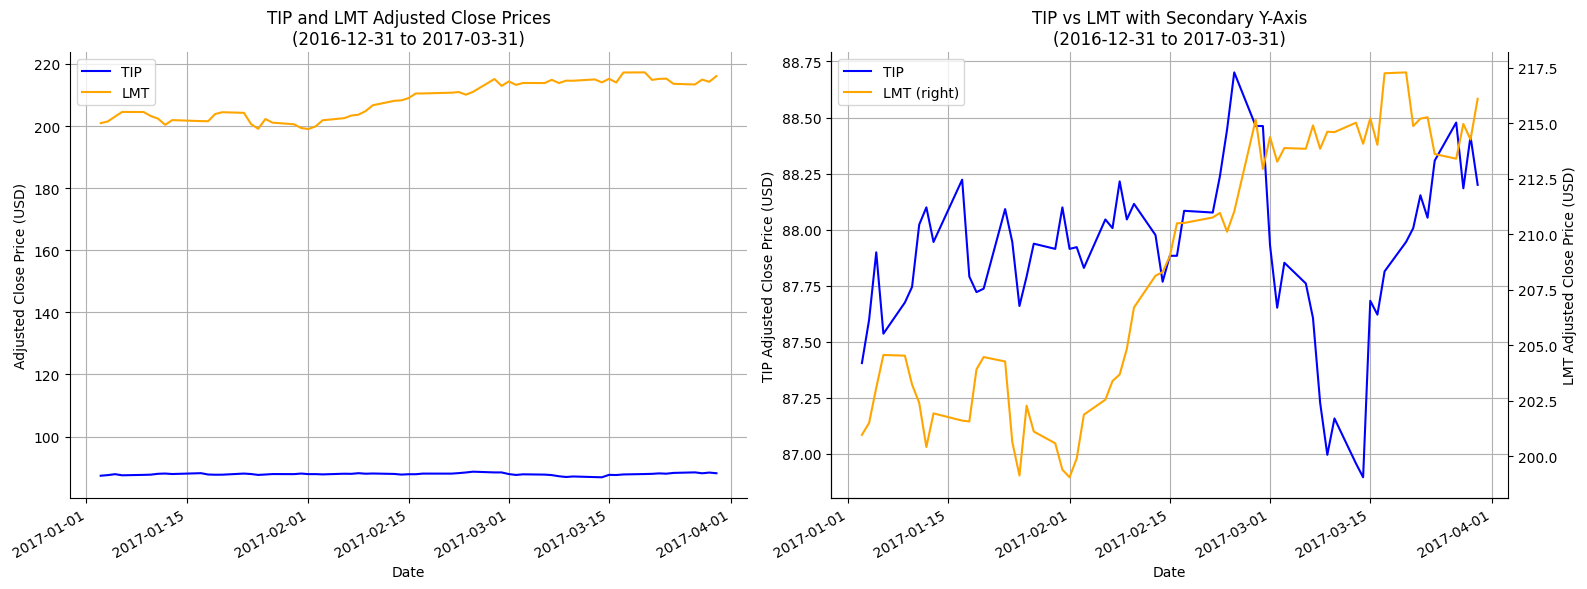

In [17]:
# # Model the spread
# S1 = data['HPQ']
# S2 = data['LMT']

S1 = data['TIP']
S2 = data['LMT']

# S1 = data['HPQ']
# S2 = data['XOM']
	
# S1 = data['TECL']
# S2 = data['SPY']

# S1 = data['TECL']
# S2 = data['EWJ']

# S1 = data['AGQ']
# S2 = data['DAL']

# S1 = data['DAL']
# S2 = data['AGQ']


# S1 = data['EWA']
# S2 = data['TIP']

# S1 = data['HEDJ']
# S2 = data['LMT']

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Subplot 1: Single y-axis (original scale)
S1.plot(label=S1.name, color='blue', ax=ax1)
S2.plot(label=S2.name, color='orange', ax=ax1)
ax1.set_title(f'{S1.name} and {S2.name} Adjusted Close Prices\n({start_date} to {end_date})')
ax1.set_xlabel('Date')
ax1.set_ylabel('Adjusted Close Price (USD)')
ax1.legend()
ax1.grid(True)
sns.despine(ax=ax1)

# Subplot 2: Secondary y-axis (dual scale)
S1.plot(label=S1.name, color='blue', ax=ax2)
S2.plot(label=S2.name, color='orange', ax=ax2, secondary_y=True)
ax2.set_title(f'{S1.name} vs {S2.name} with Secondary Y-Axis\n({start_date} to {end_date})')
ax2.set_xlabel('Date')
ax2.set_ylabel(f'{S1.name} Adjusted Close Price (USD)')
ax2.right_ax.set_ylabel(f'{S2.name} Adjusted Close Price (USD)')

# Combine legends from both axes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2.right_ax.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax2.grid(True)
sns.despine(ax=ax2)
sns.despine(ax=ax2.right_ax, right=False)

# Adjust layout to prevent overlap
plt.tight_layout()

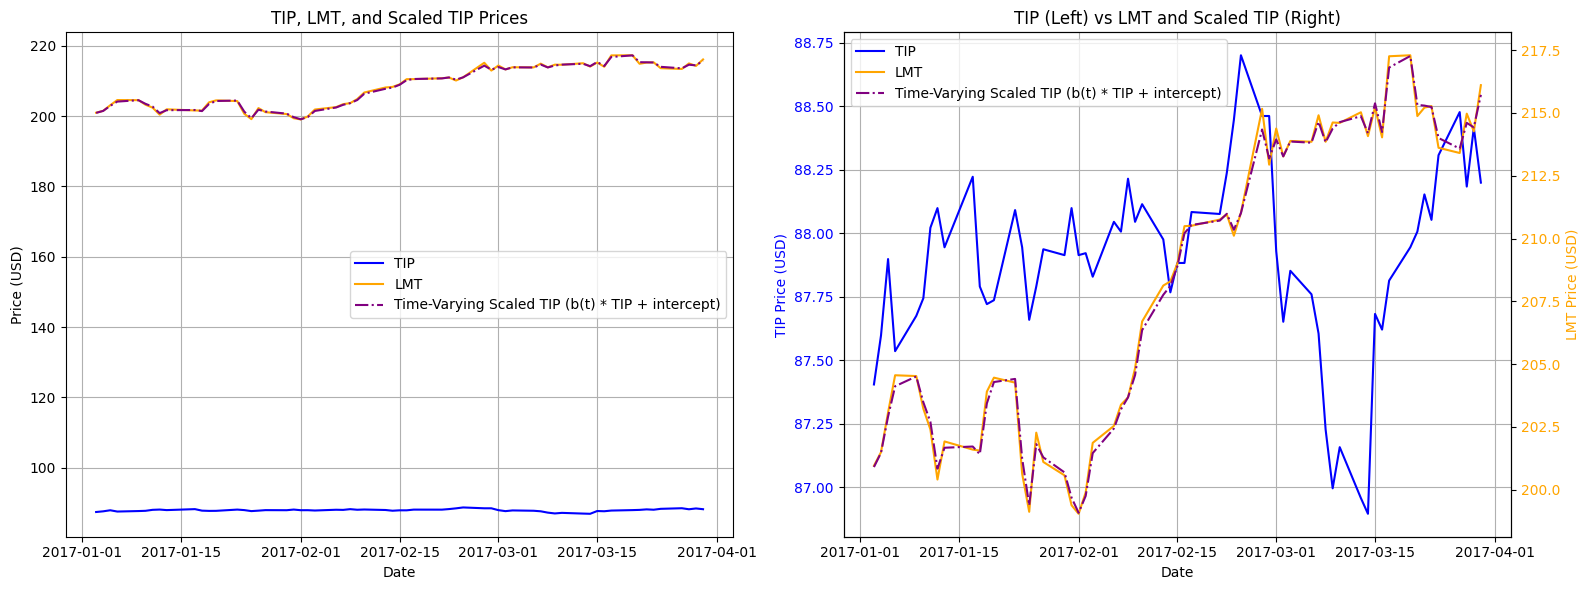

In [18]:
# Kalman Filter function to estimate hedge ratio
def KFHedgeRatio(x, y):
    """Estimate Hedge Ratio and Intercept using Kalman Filter"""
    delta = 1e-3
    trans_cov = delta / (1 - delta) * np.eye(2)
    obs_mat = np.expand_dims(np.vstack([[x], [np.ones(len(x))]]).T, axis=1)

    kf = KalmanFilter(n_dim_obs=1, n_dim_state=2,
                      initial_state_mean=[0, 0],
                      initial_state_covariance=np.ones((2, 2)),
                      transition_matrices=np.eye(2),
                      observation_matrices=obs_mat,
                      observation_covariance=2,
                      transition_covariance=trans_cov)

    state_means, _ = kf.filter(y.values)
    return state_means[:, 0], state_means[:, 1]

# Calculate hedge ratio and intercept using Kalman Filter
hedge_ratio, intercept = KFHedgeRatio(S1, S2)

# Create a time-varying spread using the Kalman Filter hedge ratio
spread = S2 - hedge_ratio * S1 - intercept

# Define scaled_S1_time_varying
scaled_S1_time_varying = pd.Series(hedge_ratio * S1 + intercept, index=S1.index)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Subplot 1: Original plot (S1, S2, and scaled S1 on the same axis)
ax1.plot(S1.index, S1.values, label=S1.name, color='blue')
ax1.plot(S2.index, S2.values, label=S2.name, color='orange')
ax1.plot(scaled_S1_time_varying.index, scaled_S1_time_varying.values,
         label=f'Time-Varying Scaled {S1.name} (b(t) * {S1.name} + intercept)',
         color='purple', linestyle='-.')
ax1.set_title(f'{S1.name}, {S2.name}, and Scaled {S1.name} Prices')
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD)')
ax1.legend()
ax1.grid(True)

# Subplot 2: Scaled plot (S1 on left axis, S2 and scaled S1 on right axis)
ax2.plot(S1.index, S1.values, label=S1.name, color='blue')
ax2.set_ylabel(f'{S1.name} Price (USD)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.set_xlabel('Date')
ax2.grid(True)

# Create right axis for S2 and scaled S1
right_ax = ax2.twinx()
right_ax.plot(S2.index, S2.values, label=S2.name, color='orange')
right_ax.plot(scaled_S1_time_varying.index, scaled_S1_time_varying.values,
              label=f'Time-Varying Scaled {S1.name} (b(t) * {S1.name} + intercept)',
              color='purple', linestyle='-.')
right_ax.set_ylabel(f'{S2.name} Price (USD)', color='orange')
right_ax.tick_params(axis='y', labelcolor='orange')

# Combine legends from both axes in subplot 2
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = right_ax.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax2.set_title(f'{S1.name} (Left) vs {S2.name} and Scaled {S1.name} (Right)')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

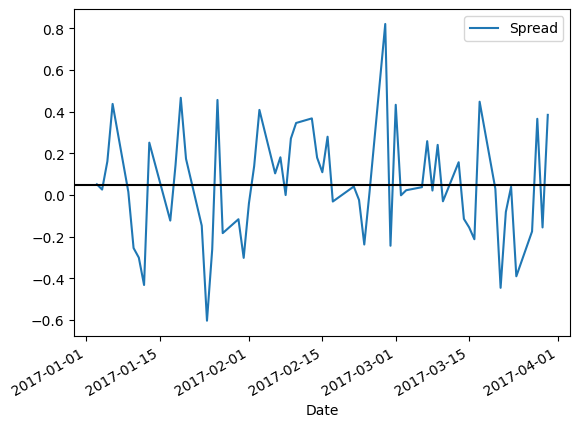

In [19]:
# Plot the spread
spread.plot()
plt.axhline(spread.mean(), color='black')
plt.legend(['Spread'])
plt.show()


half_life: 1


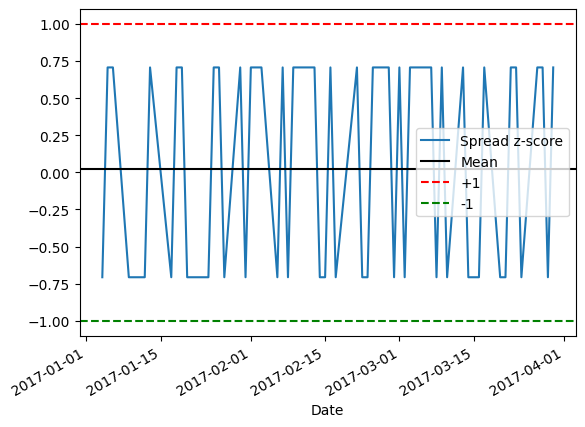

In [20]:
# Function to estimate half-life (single value for simplicity)
def estimate_half_life(spread):
    X = spread.shift().iloc[1:].to_frame().assign(const=1)
    y = spread.diff().iloc[1:]
    beta = (np.linalg.inv(X.T @ X) @ X.T @ y).iloc[0]
    halflife = int(round(-np.log(2) / beta, 0))
    return max(halflife, 1)

def simple_zscore(series):
    return (series - series.mean()) / np.std(series)

# Estimate half-life on the spread (using full period for initial window, later rolling)
half_life = estimate_half_life(spread)
print(f"half_life: {half_life}")

# Set max_window
max_window = len(spread)

# Compute rolling z-score using min(2 * half_life, max_window) as window
window = min(2 * half_life, max_window)
rolling = spread.rolling(window=window)
z_score = spread.sub(rolling.mean()).div(rolling.std())
# z_score = simple_zscore(spread)
# Plot the z-score
z_score.plot()
plt.axhline(z_score.mean(), color='black')
plt.axhline(1, color='red', linestyle='--')
plt.axhline(-1, color='green', linestyle='--')
plt.legend(['Spread z-score', 'Mean', '+1', '-1'])
plt.show()

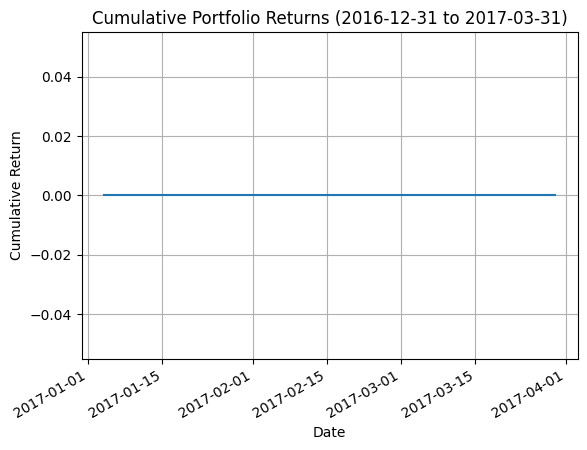

In [21]:
# Create trading signals
trades = pd.concat([z_score, spread], axis=1)
trades.columns = ["signal", "position"]

# Add long and short positions
trades["side"] = 0.0
trades.loc[trades.signal <= -1, "side"] = 1
trades.loc[trades.signal >= 1, "side"] = -1

# Fix return calculation
# Shift side to align with future returns (decision at t-1 for return from t-1 to t)
trades['side_shifted'] = trades.side.shift(1)

# Calculate daily returns for each leg
ret_S2 = S2.pct_change()
ret_S1 = S1.pct_change()

# Align hedge ratio (use previous day's hedge ratio for today's return)
hedge_ratio_shifted = pd.Series(hedge_ratio, index=S1.index).shift(1)

# Portfolio return: long S2, short hedge_ratio * S1 when side=1 (long spread)
port_ret = (ret_S2 - hedge_ratio_shifted * ret_S1) * trades.side_shifted

# Plot cumulative returns
port_ret.cumsum().plot()
plt.title(f'Cumulative Portfolio Returns ({start_date} to {end_date})')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.grid(True)
plt.show()